In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Load data
df = pd.read_csv('../../Data/bank-full.csv', delimiter=';')

# Check data
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (45211, 17)

First few rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Check data types and missing values
print("Data Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing values:
age          0
job          0
marital      0
education    0
defaul

In [4]:
# Check target variable distribution
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nPercentages:")
print(df['y'].value_counts(normalize=True) * 100)

Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [5]:
# Define features and target
target = 'y'

numeric_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

print("Target:", target)
print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Target: y

Numeric features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [6]:
# Prepare features and target
all_features = numeric_features + categorical_features
X = df[all_features]

y = df[target]

print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])
print("\nTarget distribution:")
print(df['y'].value_counts())

Feature matrix shape: (45211, 16)
Number of features: 16

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


In [7]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 36168
Test set size: 9043

Training set class distribution:
y
no     31937
yes     4231
Name: count, dtype: int64

Test set class distribution:
y
no     7985
yes    1058
Name: count, dtype: int64


In [8]:
# Build pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)


In [9]:
# Model 1: Logistic Regression with pipeline
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Model 2: Gradient Boosting Classifier with pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)
print("\nBoth models trained successfully")


Both models trained successfully


In [10]:
# Make predictions with both models
y_pred_logreg = log_reg_pipeline.predict(X_test)
y_pred_gb = gb_pipeline.predict(X_test)

# Get probability predictions
y_proba_logreg = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("First 10 test predictions (Gradient Boosting):")
for i in range(10):
    actual = y_test.iloc[i]
    predicted = y_pred_gb[i]
    prob = y_proba_gb[i]
    print(f"  Actual: {actual:3s}, Predicted: {predicted:3s}, Probability: {prob:.3f}")

First 10 test predictions (Gradient Boosting):
  Actual: no , Predicted: no , Probability: 0.008
  Actual: no , Predicted: no , Probability: 0.007
  Actual: no , Predicted: no , Probability: 0.006
  Actual: no , Predicted: no , Probability: 0.006
  Actual: no , Predicted: no , Probability: 0.015
  Actual: no , Predicted: no , Probability: 0.068
  Actual: no , Predicted: no , Probability: 0.005
  Actual: yes, Predicted: yes, Probability: 0.951
  Actual: no , Predicted: no , Probability: 0.005
  Actual: no , Predicted: no , Probability: 0.012


In [11]:
# Evaluate Logistic Regression
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_precision = precision_score(y_test, y_pred_logreg, pos_label='yes')
logreg_recall = recall_score(y_test, y_pred_logreg, pos_label='yes')
logreg_f1 = f1_score(y_test, y_pred_logreg, pos_label='yes')

# Evaluate Gradient Boosting
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, pos_label='yes')
gb_recall = recall_score(y_test, y_pred_gb, pos_label='yes')
gb_f1 = f1_score(y_test, y_pred_gb, pos_label='yes')

print("LOGISTIC REGRESSION:")
print(f"  Accuracy:  {logreg_accuracy:.4f} ({logreg_accuracy*100:.2f}%)")
print(f"  Precision: {logreg_precision:.4f}")
print(f"  Recall:    {logreg_recall:.4f}")
print(f"  F1-Score:  {logreg_f1:.4f}")

print("\nGRADIENT BOOSTING:")
print(f"  Accuracy:  {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")
print(f"  Precision: {gb_precision:.4f}")
print(f"  Recall:    {gb_recall:.4f}")
print(f"  F1-Score:  {gb_f1:.4f}")

# Determine best model
if gb_f1 > logreg_f1:
    print("\nBest Model: Gradient Boosting")
    best_pred = y_pred_gb
    best_proba = y_proba_gb
    test_accuracy, test_precision, test_recall, test_f1 = gb_accuracy, gb_precision, gb_recall, gb_f1
else:
    print("\nBest Model: Logistic Regression")
    best_pred = y_pred_logreg
    best_proba = y_proba_logreg
    test_accuracy, test_precision, test_recall, test_f1 = logreg_accuracy, logreg_precision, logreg_recall, logreg_f1

LOGISTIC REGRESSION:
  Accuracy:  0.9016 (90.16%)
  Precision: 0.6474
  Recall:    0.3488
  F1-Score:  0.4533

GRADIENT BOOSTING:
  Accuracy:  0.9062 (90.62%)
  Precision: 0.6423
  Recall:    0.4480
  F1-Score:  0.5278

Best Model: Gradient Boosting


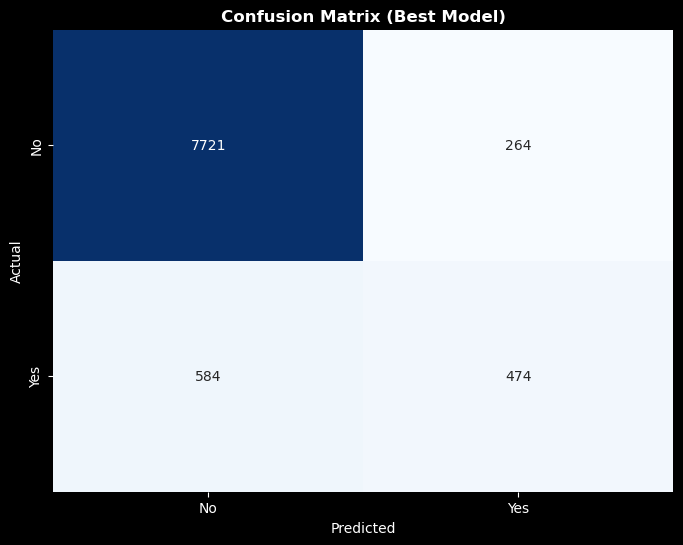

In [12]:
# Create confusion matrix for best model
cm = confusion_matrix(y_test, best_pred, labels=['no', 'yes'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Best Model)', fontweight='bold')
plt.xticks([0.5, 1.5], ['No', 'Yes'])
plt.yticks([0.5, 1.5], ['No', 'Yes'])
plt.show()


In [13]:
print("INTERPRETATION (Gradient Boosting):")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")



INTERPRETATION (Gradient Boosting):
Accuracy: 0.9062 (90.62%)
Precision: 0.6423
Recall: 0.4480
F1-Score: 0.5278


In [14]:
# Get feature importance from Gradient Boosting
if hasattr(gb_pipeline.named_steps['classifier'], 'feature_importances_'):
    # Get feature names after preprocessing
    feature_names = gb_pipeline.named_steps['preprocessor'].get_feature_names_out()
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': gb_pipeline.named_steps['classifier'].feature_importances_
    })
    
    # Sort by importance
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    # Show top 15 features
    print("Top 15 Most Important Features (Gradient Boosting):")
    print(feature_importance.head(15)[['Feature', 'Importance']].to_string(index=False))
else:
    print("Feature importance not available for this model")

Top 15 Most Important Features (Gradient Boosting):
                      Feature  Importance
            numeric__duration    0.422115
categorical__poutcome_success    0.170997
                 numeric__age    0.052866
                 numeric__day    0.049603
               numeric__pdays    0.045345
 categorical__contact_unknown    0.037671
     categorical__housing_yes    0.029069
             numeric__balance    0.028497
       categorical__month_mar    0.024698
       categorical__month_jun    0.022822
       categorical__month_oct    0.018920
            numeric__campaign    0.011170
       categorical__month_sep    0.009392
       categorical__month_may    0.007242
       categorical__month_feb    0.007233


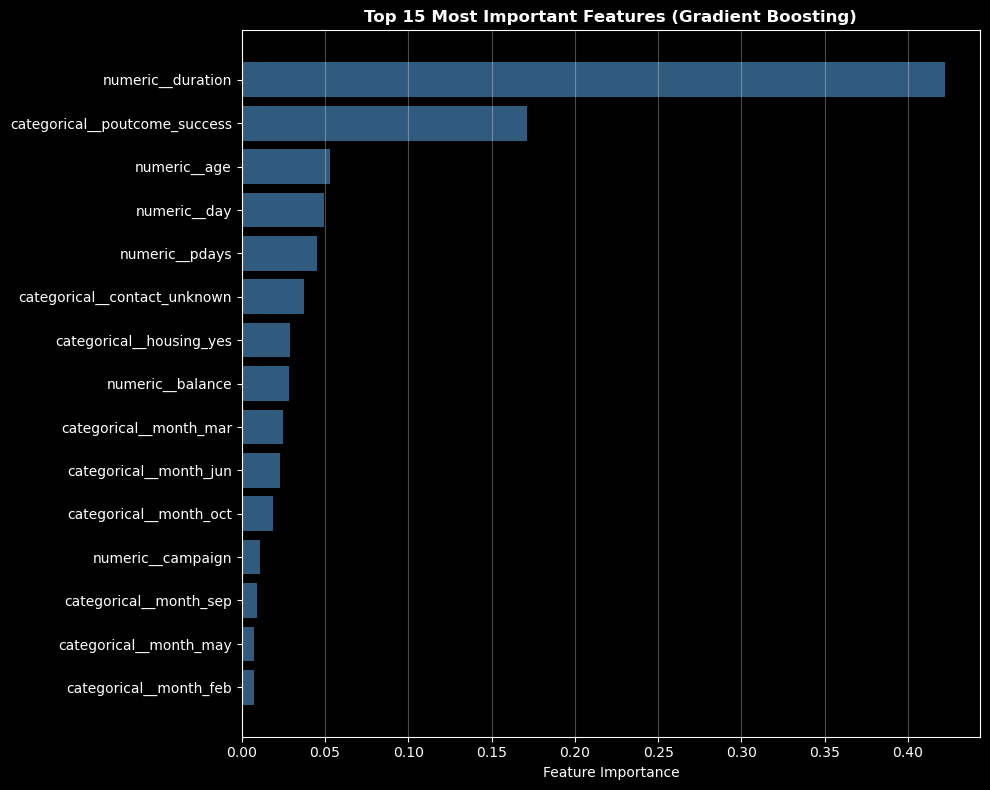

In [15]:
# Visualize top 15 features
if 'Importance' in feature_importance.columns:
    top_15 = feature_importance.head(15)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(15), top_15['Importance'], color='steelblue', alpha=0.7)
    plt.yticks(range(15), top_15['Feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Most Important Features (Gradient Boosting)', fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    

In [16]:
# Show 10 random predictions
sample_indices = np.random.choice(len(y_test), size=10, replace=False)

sample_results = pd.DataFrame({
    'Actual': [y_test.iloc[i] for i in sample_indices],
    'Predicted': [best_pred[i] for i in sample_indices],
    'Probability': best_proba[sample_indices],
    'Correct': [y_test.iloc[i] == best_pred[i] for i in sample_indices]
})

print("Sample Predictions (Best Model):")
print(sample_results.to_string(index=False))
print(f"\nAccuracy on these samples: {sample_results['Correct'].mean()*100:.1f}%")

Sample Predictions (Best Model):
Actual Predicted  Probability  Correct
    no        no     0.016761     True
    no        no     0.004443     True
    no        no     0.013864     True
   yes        no     0.168603    False
   yes       yes     0.608765     True
    no        no     0.349226     True
    no        no     0.026795     True
    no        no     0.023898     True
    no        no     0.035075     True
    no        no     0.067705     True

Accuracy on these samples: 90.0%
